In [100]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.io as pio

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pointbiserialr

pio.templates.default = "plotly_dark"

In [101]:
df_healthy = pd.read_parquet("../../data/processed/dataset_features.parquet")

print(df_healthy["age"].value_counts())
print(df_healthy["gender"].value_counts())
print(df_healthy["handedness"].value_counts())
print(df_healthy["education"].value_counts())
print(df_healthy["drug"].value_counts())

# garantir tipos
df_healthy["age"] = df_healthy["age"].astype(str)
df_healthy["gender"] = df_healthy["gender"].astype(str)
df_healthy["handedness"] = df_healthy["handedness"].astype(str)
df_healthy["education"] = df_healthy["education"].astype(str)
df_healthy["drug"] = df_healthy["drug"].astype(str)


age
25-30    24
20-25    16
65-70     4
30-35     4
60-65     2
55-60     2
70-75     2
Name: count, dtype: int64
gender
2    38
1    16
Name: count, dtype: int64
handedness
right          50
left            2
ambedextor      2
Name: count, dtype: int64
education
gymnasium     40
realschule    12
gymansium      2
Name: count, dtype: int64
drug
0.0    54
Name: count, dtype: int64


In [102]:
# Organizando as variáveis
df_healthy["age_group"] = df_healthy["age"].replace({
    "20-25": "young",
    "25-30": "young",
    "30-35": "young",
    "35-40": "young",
    "55-60": "older",
    "60-65": "older",
    "65-70": "older",
    "70-75": "older"
})

# Calculando as médias das métricas
degree_cols = [c for c in df_healthy.columns if c.startswith("degree_")]
clustering_cols = [c for c in df_healthy.columns if c.startswith("clustering_")]
efficiency_cols = [c for c in df_healthy.columns if c.startswith("efficiency_")]
betweenness_cols = [c for c in df_healthy.columns if c.startswith("betweenness_")]
df_healthy["degree_mean"] = df_healthy[degree_cols].mean(axis=1)
df_healthy["clustering_mean"] = df_healthy[clustering_cols].mean(axis=1)
df_healthy["efficiency_global"] = df_healthy[efficiency_cols].mean(axis=1)
df_healthy["betweenness_mean"] = df_healthy[betweenness_cols].mean(axis=1)


In [103]:

GRAPH_METRICS = [
    "degree_mean",
    "clustering_mean",  
    "betweenness_mean"
]

sample_summary = (
    df_healthy[["subject_id", "age_group", "gender"]]
    .drop_duplicates()
    .groupby(["age_group", "gender"])
    .size()
    .reset_index(name="n")
)

sample_summary

,age_group,gender,n
0,older,1,2
1,older,2,3
2,young,1,6
3,young,2,16


In [104]:
df_healthy[["age_group", "gender"]].value_counts()

age_group  gender
young      2         32
           1         12
older      2          6
           1          4
Name: count, dtype: int64

In [105]:
df_healthy["efficiency_global"].describe()


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: efficiency_global, dtype: float64

### Idade

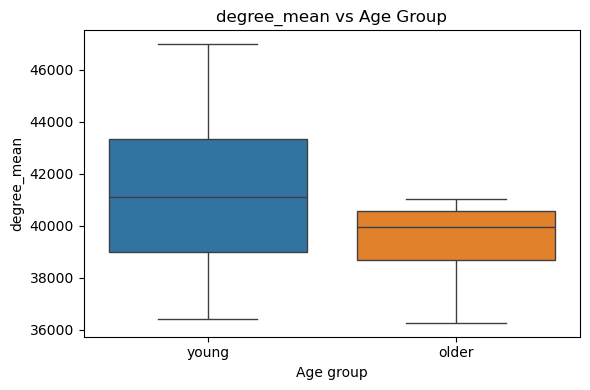

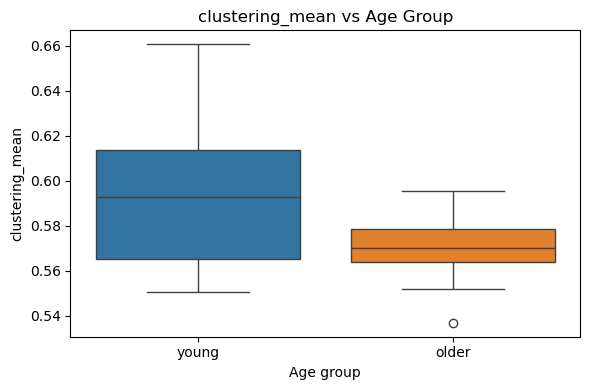

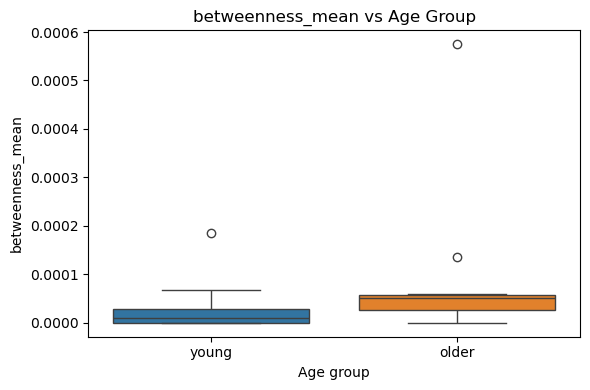

In [106]:
# Boxplot Age Group
for metric in GRAPH_METRICS:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=df_healthy,
        x="age_group",
        y=metric,
        hue="age_group",
        legend=False
    )
    plt.title(f"{metric} vs Age Group")
    plt.xlabel("Age group")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


In [107]:

# plotly
for metric in GRAPH_METRICS:
    fig = px.box(
        df_healthy,
        x="age_group",
        y=metric,
        color="age_group",
        title=f"{metric} vs Age Group",
        points="all",
        labels={
            "age_group": "Age group",
            metric: metric
        }
    )
    fig.update_layout(
        xaxis_title="Age group",
        yaxis_title=metric,
        title=f"{metric} vs Age Group"
    )
    fig.show()

Observa-se uma diferença no número de indivíduos entre os grupos etários, com predominância do grupo de adultos jovens. Dessa forma, as análises apresentadas têm caráter exploratório e descritivo, buscando identificar tendências gerais nos padrões de conectividade funcional, e não inferências estatísticas conclusivas.

-------

### Condition

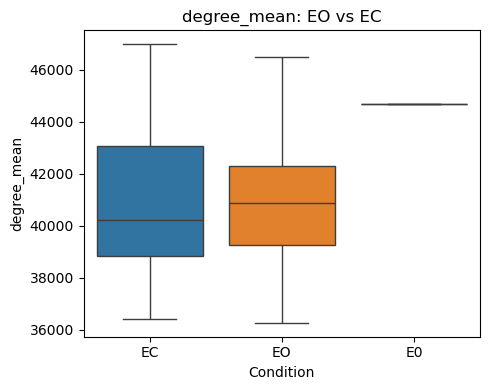

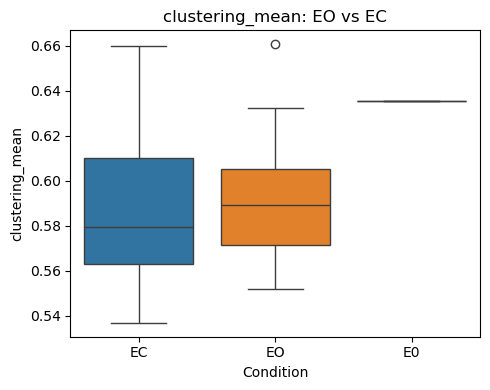

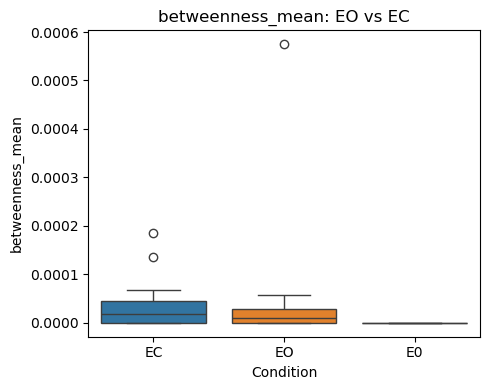

In [108]:
# Boxplot Condition
for metric in GRAPH_METRICS:
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=df_healthy,
        x="condition",
        y=metric,
        hue="condition",
        legend=False
    )
    plt.title(f"{metric}: EO vs EC")
    plt.xlabel("Condition")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

In [109]:

# plotly
for metric in GRAPH_METRICS:
    fig = px.box(
        df_healthy,
        x="condition",
        y=metric,
        color="condition",
        title=f"{metric} vs Condition",
        points="all",
        labels={
            "condition": "Condition",
            metric: metric
        }
    )
    fig.update_layout(
        xaxis_title="Condition",
        yaxis_title=metric,
        title=f"{metric} vs Condition"
    )
    fig.show()

------

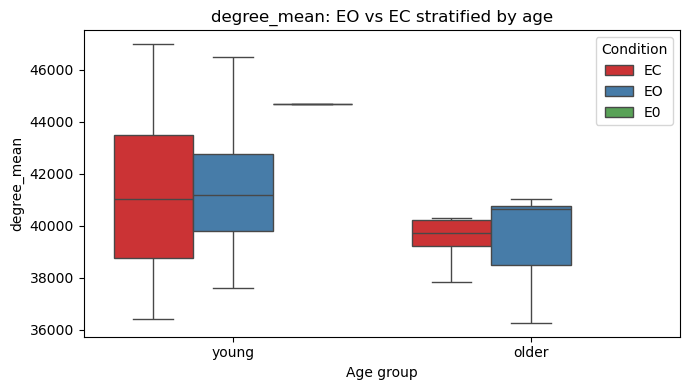

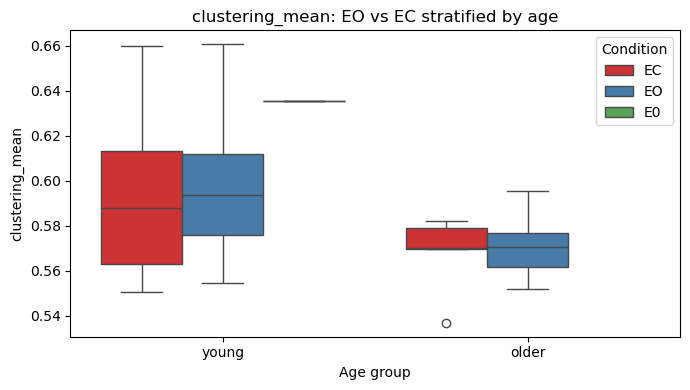

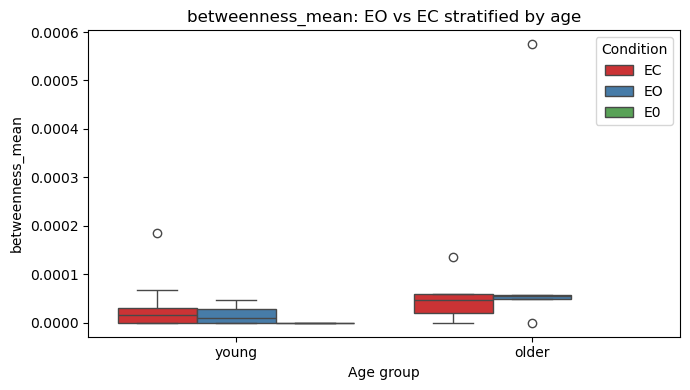

In [110]:
# Boxplot Age Group x Condition
for metric in GRAPH_METRICS:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df_healthy,
        x="age_group",
        y=metric,
        hue="condition",
        palette="Set1"
    )
    plt.title(f"{metric}: EO vs EC stratified by age")
    plt.xlabel("Age group")
    plt.ylabel(metric)
    plt.legend(title="Condition")
    plt.tight_layout()
    plt.show()

In [111]:
# plotly
for metric in GRAPH_METRICS:
    fig = px.box(
        df_healthy,
        x="age_group",
        y=metric,
        color="condition",
        title=f"{metric} vs Age Group",
        points="all",
        labels={
            "age_group": "Age group",
            metric: metric
        }
    )
    fig.update_layout(
        xaxis_title=f"{metric}: EO vs EC stratified by age",
        yaxis_title=metric,
        title=f"{metric} vs Age Group"
    )
    fig.show()

A Figura X apresenta a comparação do grau médio e do coeficiente de agrupamento médio das redes funcionais cerebrais entre os estados de olhos abertos (EO) e olhos fechados (EC), estratificada por grupo etário. Observa-se que indivíduos jovens apresentam maior variabilidade nas métricas analisadas, enquanto o grupo de indivíduos mais velhos apresenta distribuições mais concentradas. Em ambos os grupos etários, as diferenças entre EO e EC são menos pronunciadas do que aquelas associadas à idade, sugerindo que o fator etário exerce maior influência sobre a organização topológica das redes do que o estado fisiológico momentâneo.

------------------

### Correlações

In [112]:
# Correlation Age Group
age_ord_map = {"young": 0, "middle": 1, "older": 2}
df_healthy["age_ord"] = df_healthy["age_group"].map(age_ord_map)

corr_results = []

for metric in GRAPH_METRICS:
    valid = df_healthy[[metric, "age_ord"]].dropna()
    r, p = spearmanr(valid["age_ord"], valid[metric])
    corr_results.append({
        "metric": metric,
        "spearman_r": r,
        "p_value": p
    })

pd.DataFrame(corr_results)

,metric,spearman_r,p_value
0,degree_mean,-0.275288,0.043934
1,clustering_mean,-0.315052,0.020319
2,betweenness_mean,0.380252,0.004564


redes funcionais tendem a apresentar menor conectividade média em indivíduos mais velhos.

possível redução da segregação local das redes funcionais com o envelhecimento.

com o envelhecimento, a comunicação funcional pode se tornar mais dependente de nós específicos, indicando possível perda de redundância global.

Para investigar a relação entre idade e as propriedades topológicas das redes funcionais cerebrais, foi realizada uma análise de correlação de Spearman entre as métricas globais de rede e uma codificação ordinal dos grupos etários. Observou-se uma correlação negativa fraca entre a idade e o grau médio (ρ = −0,28; p < 0,05), bem como entre a idade e o coeficiente de agrupamento médio (ρ = −0,32; p < 0,05), indicando uma tendência de redução da conectividade média e da segregação local com o envelhecimento. Em contraste, a centralidade de intermediação média apresentou correlação positiva moderada com a idade (ρ = 0,38; p < 0,01), sugerindo maior dependência de nós intermediários na comunicação funcional em indivíduos mais velhos. Esses resultados devem ser interpretados de forma exploratória, considerando o tamanho reduzido e o desbalanceamento da amostra.

Com o envelhecimento, a rede funcional pode se tornar mais esparsa, o que reduz o grau e o clustering médios e faz com que a comunicação dependa mais de poucos nós intermediários — aumentando a betweenness.

Uma interpretação complementar para os resultados observados é que o envelhecimento esteja associado a uma progressiva esparsificação das redes funcionais cerebrais. A redução do grau médio e do coeficiente de agrupamento sugere uma diminuição tanto da densidade global quanto da conectividade local das redes. Como consequência, a comunicação funcional tende a se apoiar em um número menor de nós intermediários, o que se reflete no aumento da centralidade de intermediação média. Esse padrão indica uma possível perda de redundância funcional e maior vulnerabilidade da rede, sendo consistente com modelos de envelhecimento cerebral descritos na literatura.

Gênero

In [113]:
df_healthy["gender"].value_counts()

gender
2    38
1    16
Name: count, dtype: int64

In [114]:
df_healthy["gender"].dtype
df_healthy["gender"].unique()


array(['2', '1'], dtype=object)

In [115]:
df_healthy["gender"] = df_healthy["gender"].astype(float).astype(int)

df_healthy["gender_bin"] = df_healthy["gender"].map({
    1: 0,  # female
    2: 1   # male
})

df_healthy['gender_bin'].value_counts()


gender_bin
1    38
0    16
Name: count, dtype: int64

In [116]:
gender_results = []

for metric in GRAPH_METRICS:
    valid = df_healthy[[metric, "gender_bin"]].dropna()
    r, p = pointbiserialr(valid["gender_bin"], valid[metric])
    gender_results.append({
        "metric": metric,
        "point_biserial_r": r,
        "p_value": p
    })

pd.DataFrame(gender_results)



,metric,point_biserial_r,p_value
0,degree_mean,0.053429,0.701195
1,clustering_mean,0.025341,0.855671
2,betweenness_mean,-0.187036,0.175656


A análise da relação entre gênero e métricas globais de conectividade funcional cerebral foi realizada por meio da correlação ponto-biserial. Os resultados não indicaram associação estatisticamente significativa entre gênero e as métricas de grau médio, coeficiente de agrupamento médio e centralidade de intermediação média (p > 0,05 em todos os casos). Além disso, os valores de correlação observados foram próximos de zero, sugerindo efeito desprezível do gênero sobre a organização global das redes funcionais cerebrais em indivíduos saudáveis. Esses achados estão em consonância com estudos que apontam que diferenças relacionadas ao gênero tendem a se manifestar de forma mais localizada ou dependente de tarefas específicas, sendo menos evidentes em métricas globais de conectividade em estado de repouso.

Idade

In [117]:
age_ord_map = {"young": 0, "older": 1}
df_healthy["age_ord"] = df_healthy["age_group"].map(age_ord_map)

corr_results = []

for metric in GRAPH_METRICS:
    valid = df_healthy[[metric, "age_ord"]].dropna()
    r, p = spearmanr(valid["age_ord"], valid[metric])
    corr_results.append({
        "metric": metric,
        "spearman_r": r,
        "p_value": p
    })

pd.DataFrame(corr_results)

,metric,spearman_r,p_value
0,degree_mean,-0.275288,0.043934
1,clustering_mean,-0.315052,0.020319
2,betweenness_mean,0.380252,0.004564


A relação entre envelhecimento e propriedades topológicas das redes funcionais cerebrais foi investigada por meio da correlação de Spearman, considerando grupos etários ordenados. Os resultados indicaram correlação negativa significativa entre idade e o grau médio (ρ = −0,28; p < 0,05) e o coeficiente de agrupamento médio (ρ = −0,32; p < 0,05), bem como correlação positiva significativa com a centralidade de intermediação média (ρ = 0,38; p < 0,01). Esses achados sugerem que o envelhecimento está associado a redes funcionais mais esparsas, com menor integração e segregação local, e maior dependência de nós intermediários para a comunicação global, caracterizando uma reorganização topológica compatível com padrões descritos na literatura sobre envelhecimento saudável.

Os resultados indicam que, mesmo em indivíduos saudáveis, o envelhecimento está associado a uma reorganização topológica global das redes funcionais, com redução da densidade e modularidade e aumento da dependência de nós intermediários, o que sugere maior custo e fragilidade na comunicação funcional.